In [1]:
import numpy as np
import random
import pylab as plt
plt.rcParams['figure.figsize'] = [8, 5]

In [2]:
#goat = 0
#car = 1 
#switcher = decides to switch sides
#conservative = decides to stick on its first choice
#newcomer = arrives with an open door with a goat and two closed doors

#probabilities
p_car = 1/3
p_goat = 2/3

#switcher p = p(car,goat)*p(goat) + p(goat,car)*p(car) = 2/3
p_switcher = (1/2)*p_goat + p_car 

#conservative = 1/3
p_conservative = p_car

#newcomer = p(car,goat)
p_newcomer = p_car / p_goat

In [25]:
trials = int(1e5)
switcher_wins = 0
conservative_wins = 0
newcomer_wins = 0
index_array = np.array([0, 1, 2])
    

for j in range(trials):
    random_doors = np.array([1]*1 + [0]*2)
    np.random.shuffle(random_doors)
    
    #scelta del partecipante
    index_choice= np.random.choice(index_array)
    
    #logica del conduttore
    possible_index_conductor = []
    for i in range(len(random_doors)):
            if(i != index_choice and random_doors[i] == 0):
                possible_index_conductor.append(i)
    
    conductor_choice = np.random.choice(possible_index_conductor)
    
    #switcher
    index_switcher = 0
    for i in range(len(random_doors)):
        if i != index_choice and i != conductor_choice:
            index_switcher = i
    
    if random_doors[index_switcher] == 1:
        switcher_wins = switcher_wins + 1
    
    #conservative
    if random_doors[index_choice] == 1:
        conservative_wins = conservative_wins + 1
    
    #newcomer
    newcomer_choice = 0
    index_newcomer = np.random.choice([index_switcher, index_choice])
    if random_doors[index_newcomer] == 1:
        newcomer_wins = newcomer_wins + 1


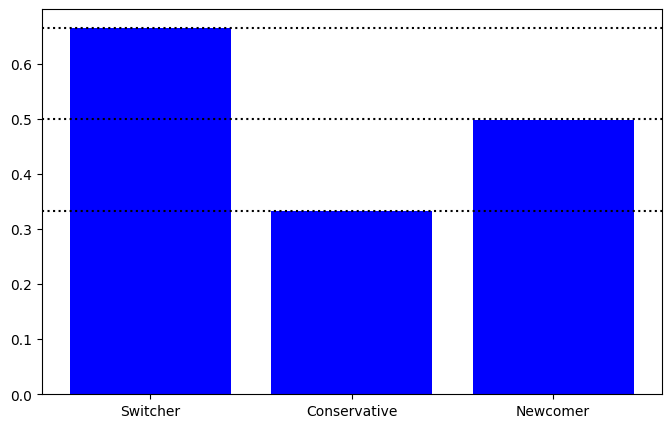

In [26]:
probs = [switcher_wins/trials, conservative_wins/trials, newcomer_wins/trials]
nomi = ["Switcher", "Conservative", "Newcomer"]

plt.bar([0, 1, 2], probs, color='blue')
plt.xticks([0, 1, 2], nomi)


for y in [p_switcher,p_conservative,p_newcomer]:
    plt.axhline(y, ls='dotted',c='black')

plt.savefig("istogramma_risultati.png", dpi=300, bbox_inches='tight')

In [17]:
trials = int(1e4)
#number of doors 
N_list = [int(3),int(10),int(30),int(50),int(100),int(1000), int(10000)]
#index arrays
index_arrays = [np.arange(n) for n in N_list]
#number of doors opened
p_doors = [0.25, 0.5, 0.75, 0.9]
switcher_wins_matrix = np.zeros((len(N_list), len(p_doors)))
conservative_wins_matrix = np.zeros((len(N_list), len(p_doors)))
newcomer_wins_matrix = np.zeros((len(N_list), len(p_doors)))

for i in range(len(N_list)): #numero di porte
    N = N_list[i] 
    current_indices = index_arrays[i]
    for j in range(len(p_doors)): #numero di porte aperte
        frac = p_doors[j]
        p_eff = int(frac * int(N-1))

        switcher_count = 0
        conservative_count = 0
        newcomer_count = 0
        for k in range(trials):
            random_doors = np.array([1]*1 + [0]*int(N-1))
            np.random.shuffle(random_doors)

            player_choice= np.random.choice(index_arrays[i])

            possible_to_open = []
            for idx in index_arrays[i]:
                if(idx != player_choice and random_doors[int(idx)] != 1):
                    possible_to_open.append(idx)

            #apertura porte
            opened = np.random.choice(possible_to_open, p_eff, replace=False)
            opened_set = set(opened)
            
            #switcher
            still_closed_doors = []
            for idx in index_arrays[i]:
                if(idx != player_choice and idx not in opened_set):
                    still_closed_doors.append(idx)

            switch_choice = np.random.choice(still_closed_doors)
            if random_doors[switch_choice] == 1:
                switcher_count = switcher_count + 1
            
            #conservative
            if random_doors[player_choice] == 1:
                conservative_count = conservative_count + 1

            #newcomer
            all_closed_doors = []
            for idx in index_arrays[i]:
                if(idx not in opened_set):
                    all_closed_doors.append(idx)

            newcomer_choice = np.random.choice(all_closed_doors)
            if random_doors[newcomer_choice] == 1:
                newcomer_count = newcomer_count + 1
        print("Finito N = "+ str(N) + " p = " + str(p_eff))

        switcher_wins_matrix[i, j] = switcher_count / trials
        conservative_wins_matrix[i, j] = conservative_count / trials
        newcomer_wins_matrix[i, j] = newcomer_count / trials

print("Simulazione completata.")

Finito N = 3 p = 0
Finito N = 3 p = 1
Finito N = 3 p = 1
Finito N = 3 p = 1
Finito N = 10 p = 2
Finito N = 10 p = 4
Finito N = 10 p = 6
Finito N = 10 p = 8
Finito N = 30 p = 7
Finito N = 30 p = 14
Finito N = 30 p = 21
Finito N = 30 p = 26
Finito N = 50 p = 12
Finito N = 50 p = 24
Finito N = 50 p = 36
Finito N = 50 p = 44
Finito N = 100 p = 24
Finito N = 100 p = 49
Finito N = 100 p = 74
Finito N = 100 p = 89
Finito N = 1000 p = 249
Finito N = 1000 p = 499
Finito N = 1000 p = 749
Finito N = 1000 p = 899
Finito N = 10000 p = 2499
Finito N = 10000 p = 4999
Finito N = 10000 p = 7499
Finito N = 10000 p = 8999
Simulazione completata.


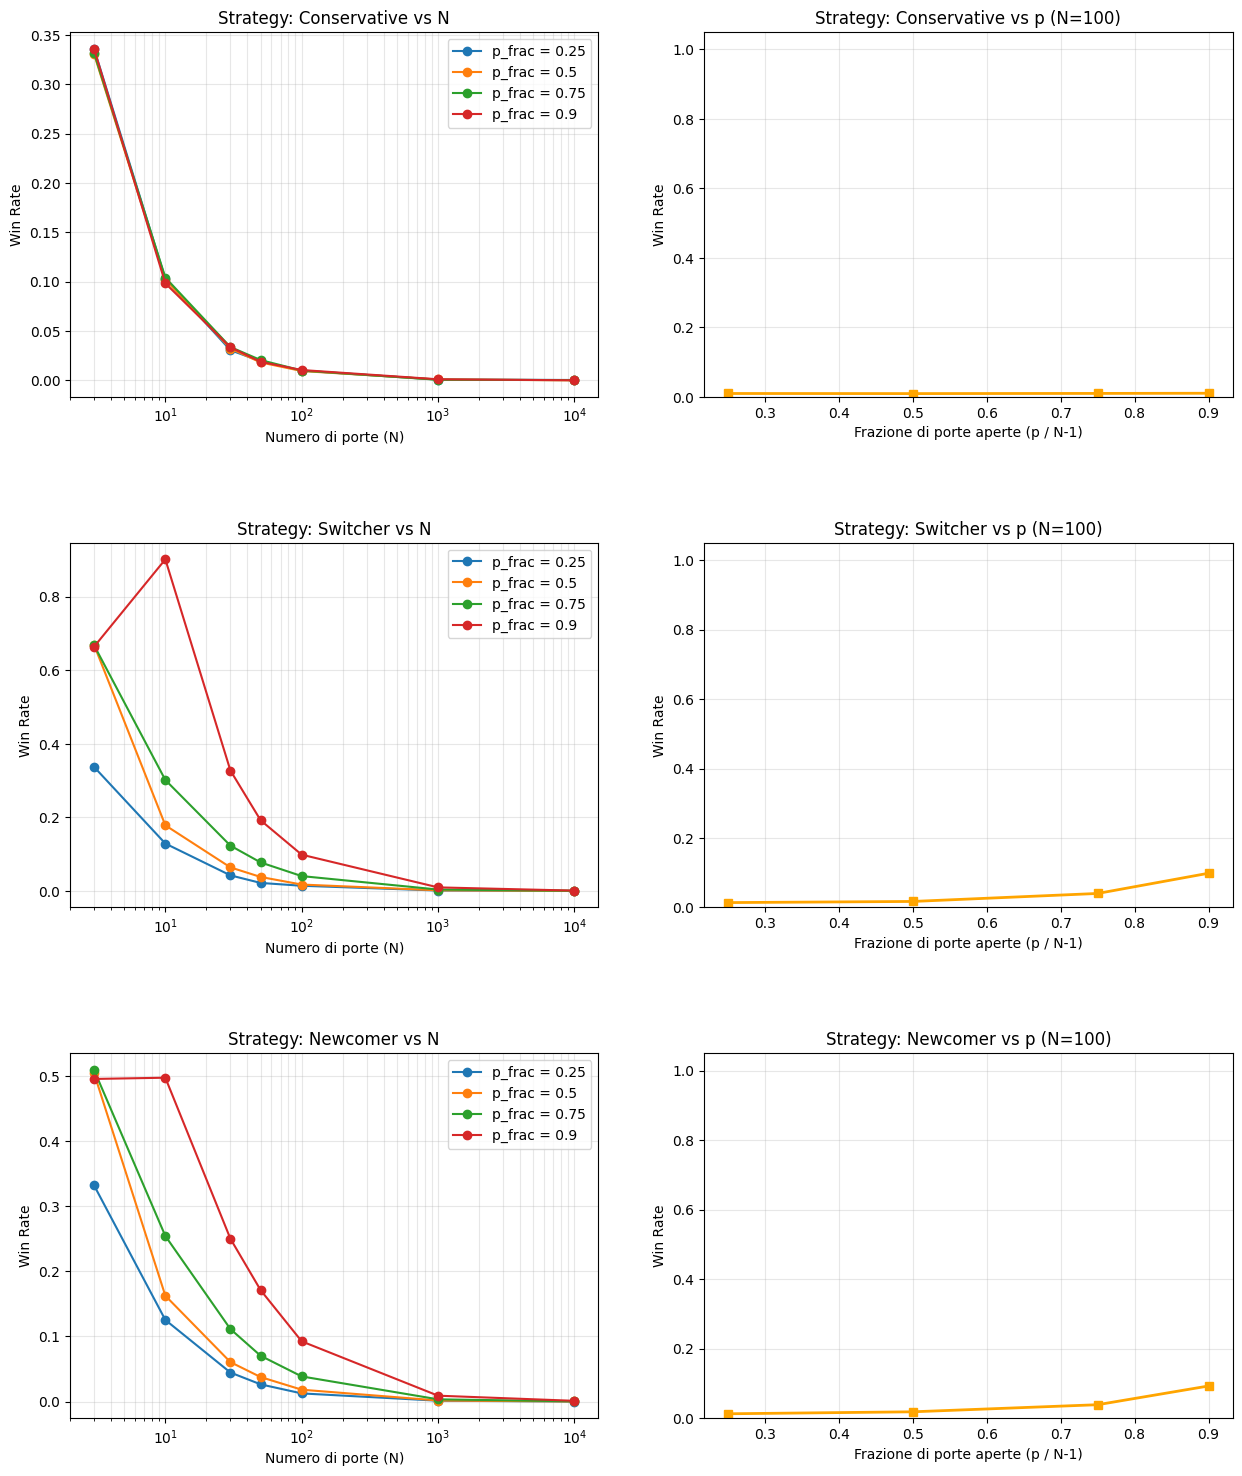

In [22]:
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
plt.subplots_adjust(hspace=0.4)

titles = ["Strategy: Conservative", "Strategy: Switcher", "Strategy: Newcomer"]
matrices = [conservative_wins_matrix, switcher_wins_matrix, newcomer_wins_matrix]

for i in range(3):
    matrix = matrices[i]
    
    # --- Grafico 1: In funzione di N (per diverse frazioni p) ---
    ax1 = axes[i, 0]
    for j, frac in enumerate(p_doors):
        ax1.plot(N_list, matrix[:, j], marker='o', label=f'p_frac = {frac}')
    
    ax1.set_title(f"{titles[i]} vs N")
    ax1.set_xlabel("Numero di porte (N)")
    ax1.set_ylabel("Win Rate")
    ax1.set_xscale('log') # Scala logaritmica per gestire N da 3 a 100.000
    ax1.legend()
    ax1.grid(True, which="both", alpha=0.3)

    # --- Grafico 2: In funzione della frazione p (per un N fissato) ---
    # Scegliamo un N intermedio, ad esempio N=100 (indice 4 se N_list=[3,10,30,50,100,1000])
    target_N_idx = 4
    ax2 = axes[i, 1]
    ax2.plot(p_doors, matrix[target_N_idx, :], marker='s', color='orange', linewidth=2)
    
    ax2.set_title(f"{titles[i]} vs p (N={N_list[target_N_idx]})")
    ax2.set_xlabel("Frazione di porte aperte (p / N-1)")
    ax2.set_ylabel("Win Rate")
    ax2.set_ylim(0, 1.05)
    ax2.grid(True, alpha=0.3)
plt.savefig("moreN.png")
plt.show()
